# 07. Проверяем курсор и город объявления

Есть идея: боты могут реже двигать курсор или чаще оставлять нулевые координаты. А самый частый город просмотренных объявлений может дать дополнительный контекст. Проверим эти признаки на тех же трёх будущих отрезках, где сравнивали прошлые модели. Итоговый файл пока не меняем.

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from utils.features import build_features
from utils.journeys import build_journey_features
from utils.pointer_location import build_pointer_location_features
from utils.metric import precision_at_recall

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

## Что именно считаем

`pointer_x_std` и `pointer_y_std` показывают разброс координат по событиям куки. Это не траектория мыши: координаты записаны лишь в некоторых событиях. При одной подходящей записи стандартное отклонение не определено, оставляем пропуск.

`counter_zeros` считает нулевые координаты: пара `(0, 0)` даёт два нуля. Рядом проверяем число событий хотя бы с одним нулём и число событий с двумя нулями. В модель сначала добавим только `counter_zeros`, чтобы не плодить почти одинаковые колонки. `top_location` означает самый частый **город объявления**, а не город проживания пользователя. Если городов поровну, берём первый по алфавиту. Все события ограничены суточным окном куки.

In [2]:
parse_dates = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv("data/train.csv", parse_dates=parse_dates)
test = pd.read_csv("data/test.csv", parse_dates=parse_dates)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

base_features, groups, n_inside = build_features(train, test, events)
journey_features, journey_groups = build_journey_features(train, test, events)
pointer_features = build_pointer_location_features(train, test, events)
features = base_features.merge(
    journey_features.drop(columns="split"), on="cookie_id", validate="one_to_one"
).merge(pointer_features, on="cookie_id", validate="one_to_one")
assert features.cookie_id.equals(pd.concat([train.cookie_id, test.cookie_id], ignore_index=True))

fit = features.iloc[:len(train)].reset_index(drop=True)
y = train.target.to_numpy()
print(f"Кук: {len(features):,} | событий внутри окон: {n_inside:,}")
print("Без двух координат хотя бы в двух событиях:",
      f"{fit.pointer_x_std.isna().mean():.1%} train")
print("С хотя бы одним нулём:", f"{fit.counter_zeros.gt(0).mean():.1%} train")
print("Разных top_location:", fit.top_location.nunique())
for name, part in [("train", features.iloc[:len(train)]), ("test", features.iloc[len(train):])]:
    print(name, "без pointer_x_std:", f"{part.pointer_x_std.isna().mean():.1%}",
          "с нулями:", f"{part.counter_zeros.gt(0).mean():.1%}",
          "медиана pointer_x_std:", f"{part.pointer_x_std.median():.1f}")

Кук: 16,000 | событий внутри окон: 288,126
Без двух координат хотя бы в двух событиях: 64.6% train
С хотя бы одним нулём: 1.8% train
Разных top_location: 41
train без pointer_x_std: 64.6% с нулями: 1.8% медиана pointer_x_std: 545.5
test без pointer_x_std: 63.9% с нулями: 1.8% медиана pointer_x_std: 536.8


## Есть ли сигнал до обучения

Сравним частоту нулевых координат у известных людей и ботов. Это только разведка: таблица использует метки train, а значит сама по себе не говорит, что модель хорошо сработает на будущих днях.

,cookies,zero_share,pointer_std_missing,pointer_x_median,pointer_y_median
target,,,,,
0,10192,0.010,0.640,552.050,308.073
1,899,0.117,0.722,200.551,200.970


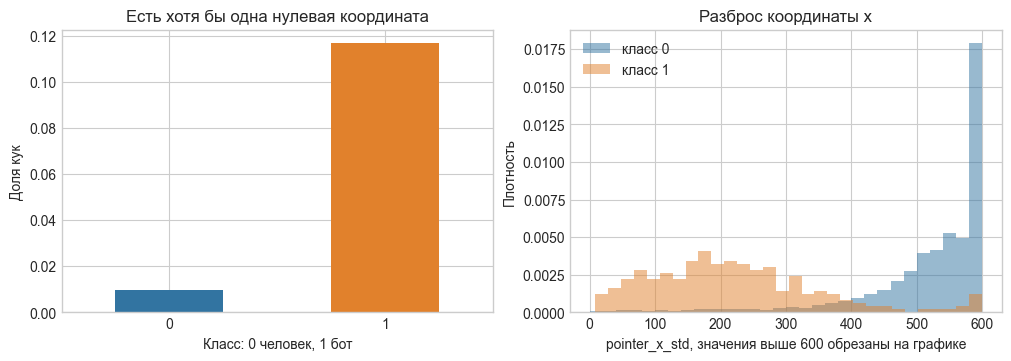

In [3]:
view = fit[["pointer_x_std", "pointer_y_std", "counter_zeros", "top_location"]].copy()
view["target"] = y
summary = view.groupby("target").agg(
    cookies=("counter_zeros", "size"),
    zero_share=("counter_zeros", lambda s: s.gt(0).mean()),
    pointer_std_missing=("pointer_x_std", lambda s: s.isna().mean()),
    pointer_x_median=("pointer_x_std", "median"),
    pointer_y_median=("pointer_y_std", "median"),
)
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
summary.zero_share.plot.bar(ax=axes[0], color=["#3274A1", "#E1812C"])
axes[0].set(xlabel="Класс: 0 человек, 1 бот", ylabel="Доля кук",
            title="Есть хотя бы одна нулевая координата")
axes[0].tick_params(axis="x", rotation=0)
for target, color in [(0, "#3274A1"), (1, "#E1812C")]:
    values = view.loc[view.target.eq(target), "pointer_x_std"].dropna().clip(upper=600)
    axes[1].hist(values, bins=30, alpha=.5, density=True, color=color,
                 label=f"класс {target}")
axes[1].set(xlabel="pointer_x_std, значения выше 600 обрезаны на графике",
            ylabel="Плотность", title="Разброс координаты x")
axes[1].legend()
plt.show()

## Честная проверка по времени

Сохраняем параметры CatBoost из прошлых ноутбуков. Меняем только набор признаков. На каждом отрезке обучаемся на более ранних куках; для `top_location` CatBoost сам обрабатывает строковую категорию. Отдельно проверяем добавление координат, города и обоих вместе. Затем сравниваем среднее рангов трёх обновлённых моделей с текущим финальным ансамблем.

In [4]:
base = [column for column in groups["base"]
        if column not in {"headless_ua", "automation_ua", "ua_count"}]
routes = base + groups["routes"]
context = routes + [column for column in journey_groups["context"]
                    if column != "seller_switch_share"]
mouse = ["pointer_x_std", "pointer_y_std", "counter_zeros"]
location = ["top_location"]
configs = {
    "base_plus": base + mouse + location,
    "routes_plus": routes + mouse + location,
    "context_mouse": context + mouse,
    "context_location": context + location,
    "context_plus": context + mouse + location,
}
folds = [
    ("11–13 апреля", "2026-04-11", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20"),
]

rows = []
predictions = []
feature_importances = []
for name, columns in configs.items():
    for fold_name, start, end in folds:
        fit_mask = fit.window_start_ts.lt(start).to_numpy()
        valid_mask = fit.window_start_ts.ge(start).to_numpy() & fit.window_start_ts.lt(end).to_numpy()
        assert fit.loc[fit_mask, "window_start_ts"].max() < fit.loc[valid_mask, "window_start_ts"].min()
        model = CatBoostClassifier(
            iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
            loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
            thread_count=4, allow_writing_files=False,
            cat_features=["top_location"] if "top_location" in columns else [],
        )
        model.fit(fit.loc[fit_mask, columns], y[fit_mask])
        score = model.predict_proba(fit.loc[valid_mask, columns])[:, 1]
        rows.append({"model": name, "fold": fold_name,
                     "p_at_r70": precision_at_recall(y[valid_mask], score)})
        predictions.append(pd.DataFrame({
            "cookie_id": fit.loc[valid_mask, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid_mask], "model": name,
            "score": score,
        }))
        if name == "context_plus":
            feature_importances.append(pd.Series(
                model.get_feature_importance(), index=columns, name=fold_name
            ))
    print("Проверено:", name)

results = pd.DataFrame(rows)
validation_long = pd.concat(predictions, ignore_index=True)
table = results.pivot(index="model", columns="fold", values="p_at_r70")
table["среднее"] = table.mean(axis=1)
display(table[[name for name, _, _ in folds] + ["среднее"]].round(3))

Проверено: base_plus


Проверено: routes_plus


Проверено: context_mouse


Проверено: context_location


Проверено: context_plus


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
base_plus,0.686,0.662,0.794,0.714
context_location,0.515,0.544,0.533,0.531
context_mouse,0.636,0.688,0.758,0.694
context_plus,0.657,0.714,0.778,0.716
routes_plus,0.650,0.678,0.806,0.711


In [5]:
keys = ["cookie_id", "fold", "target"]
new = validation_long.pivot(index=keys, columns="model", values="score").reset_index()
old_base = pd.read_csv("output/model_validation_scores.csv")[keys + ["catboost_no_ua"]]
old_routes = pd.read_csv("output/feature_validation_scores.csv")[keys + ["routes"]]
old_context = pd.read_csv("output/journey_validation_scores.csv")[keys + ["context_pruned"]]
comparison = new.merge(old_base, on=keys, validate="one_to_one").merge(
    old_routes, on=keys, validate="one_to_one"
).merge(old_context, on=keys, validate="one_to_one")
assert len(comparison) == len(new) == 6874

old_columns = ["catboost_no_ua", "routes", "context_pruned"]
new_columns = ["base_plus", "routes_plus", "context_plus"]
comparison["old_rank_mean"] = comparison.groupby("fold")[old_columns].rank(pct=True).mean(axis=1)
comparison["new_rank_mean"] = comparison.groupby("fold")[new_columns].rank(pct=True).mean(axis=1)
ensemble_rows = []
for fold_name, part in comparison.groupby("fold"):
    ensemble_rows.append({
        "fold": fold_name,
        "старый ансамбль": precision_at_recall(part.target, part.old_rank_mean),
        "новые признаки": precision_at_recall(part.target, part.new_rank_mean),
    })
ensemble_table = pd.DataFrame(ensemble_rows).set_index("fold").reindex(
    [name for name, _, _ in folds]
)
ensemble_table.loc["среднее"] = ensemble_table.mean()
display(ensemble_table.round(3))

importance = pd.concat(feature_importances, axis=1).mean(axis=1)
display(importance.loc[mouse + location].sort_values(ascending=False).round(3))

,старый ансамбль,новые признаки
fold,,
11–13 апреля,0.524,0.680
14–16 апреля,0.552,0.688
17–19 апреля,0.622,0.806
среднее,0.566,0.725


pointer_x_std    10.792
counter_zeros     1.984
top_location      1.550
pointer_y_std     1.221
dtype: float64

## Что дало прирост

По одной добавим к базовой модели разброс по x, разброс по y и число нулей. Потом проверим все три признака вместе. Отдельно сравним ансамбль с городом и без города. Это помогает не принять случайное улучшение от одной комбинации за пользу каждого признака.

In [6]:
ablations = {
    "base_x_std": base + ["pointer_x_std"],
    "base_y_std": base + ["pointer_y_std"],
    "base_zeros": base + ["counter_zeros"],
    "base_mouse": base + mouse,
    "routes_mouse": routes + mouse,
}
ablation_rows = []
ablation_predictions = []
for name, columns in ablations.items():
    for fold_name, start, end in folds:
        fit_mask = fit.window_start_ts.lt(start).to_numpy()
        valid_mask = fit.window_start_ts.ge(start).to_numpy() & fit.window_start_ts.lt(end).to_numpy()
        model = CatBoostClassifier(
            iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
            loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
            thread_count=4, allow_writing_files=False,
        )
        model.fit(fit.loc[fit_mask, columns], y[fit_mask])
        score = model.predict_proba(fit.loc[valid_mask, columns])[:, 1]
        ablation_rows.append({"model": name, "fold": fold_name,
                              "p_at_r70": precision_at_recall(y[valid_mask], score)})
        ablation_predictions.append(pd.DataFrame({
            "cookie_id": fit.loc[valid_mask, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid_mask], "model": name,
            "score": score,
        }))
    print("Проверено:", name)

ablation_table = pd.DataFrame(ablation_rows).pivot(
    index="model", columns="fold", values="p_at_r70"
)
ablation_table["среднее"] = ablation_table.mean(axis=1)
display(ablation_table[[name for name, _, _ in folds] + ["среднее"]].round(3))

ablation_wide = pd.concat(ablation_predictions).pivot(
    index=keys, columns="model", values="score"
).reset_index()
comparison = comparison.merge(ablation_wide, on=keys, validate="one_to_one")
no_location = ["base_mouse", "routes_mouse", "context_mouse"]
comparison["mouse_rank_mean"] = comparison.groupby("fold")[no_location].rank(pct=True).mean(axis=1)
blend_rows = []
for fold_name, part in comparison.groupby("fold"):
    blend_rows.append({
        "fold": fold_name,
        "старый ансамбль": precision_at_recall(part.target, part.old_rank_mean),
        "курсор, без города": precision_at_recall(part.target, part.mouse_rank_mean),
        "курсор + город": precision_at_recall(part.target, part.new_rank_mean),
    })
blend_table = pd.DataFrame(blend_rows).set_index("fold").reindex(
    [name for name, _, _ in folds]
)
blend_table.loc["среднее"] = blend_table.mean()
display(blend_table.round(3))

output = Path("output/pointer_location_validation_scores.csv")
# Средние рангов могут различаться меньше чем на 1e-10.
# Не округляем их: иначе равные группы при повторном чтении изменят метрику.
comparison.to_csv(output, index=False, float_format="%.17g")
print("Сохранены оценки для проверки:", output)

Проверено: base_x_std


Проверено: base_y_std


Проверено: base_zeros


Проверено: base_mouse


Проверено: routes_mouse


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
base_mouse,0.704,0.685,0.752,0.713
base_x_std,0.580,0.685,0.704,0.657
base_y_std,0.538,0.598,0.552,0.563
base_zeros,0.579,0.550,0.663,0.597
routes_mouse,0.619,0.695,0.765,0.693


,старый ансамбль,"курсор, без города",курсор + город
fold,,,
11–13 апреля,0.524,0.670,0.680
14–16 апреля,0.552,0.714,0.688
17–19 апреля,0.622,0.758,0.806
среднее,0.566,0.714,0.725


Сохранены оценки для проверки: output/pointer_location_validation_scores.csv


## Вывод

Признаки курсора действительно сильно помогли. Среднее рангов трёх обновлённых моделей получило **0,680 / 0,688 / 0,806** на трёх временных проверках, в среднем **0,725**. У нынешнего ответа было **0,524 / 0,552 / 0,622**, в среднем **0,566**. Прирост есть на каждом отрезке.

Самый полезный одиночный признак здесь `pointer_x_std`: с ним базовый CatBoost поднялся с 0,521 до 0,657 в среднем. Число нулевых координат дало 0,597, `pointer_y_std` дало 0,563. Вместе эти три признака дали базовой модели 0,713. Город объявления без координат не помог: контекстная модель с ним получила 0,531 против 0,536 у прежней. Но в сочетании с курсором город немного поднял среднее ансамбля с 0,714 до 0,725, хотя на среднем отрезке вариант без города оказался лучше.

Заполненность координат в train и test близка, но стандартное отклонение отсутствует примерно у 64% кук. Координаты в событиях не равны полной траектории мыши, а город относится к объявлению. Поэтому остаётся риск, что на скрытом test эффект будет слабее. `output/submission.csv` этим экспериментом не меняли: сначала стоит решить, обновляем ли финальный ответ.